
## FINANCIAL ECONOMETRICS
MODULE 7 | LESSON 3

---

# **AGENT-BASED MODELING II**

|  |  |
|:---|:---|
|**Reading Time** | 60 minutes |
|**Prior Knowledge** | Computer programming skills, basic statistics, Monte Carlo simulation  |
|**Keywords** |Agent-based modeling, Agent, Topology, Segregation Model  |


---

*In the last lesson, we went through the overview of the agent-based model (ABM) and introduced the segregation model as an example. In this lesson, we will continue our discussion of ABM. We will go into more detail on the three components of ABM. Then, we will talk about the types of results and model validation of ABM. We will finish the lesson with a demonstration of the programming procedure for an ABM example.*<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [1]:
import copy
import itertools

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

## **1. Three components of Agent-Based Models**

### **1.1  Agent Characteristics**

Like we stated in the previous lesson, an agent can be a consumer, a trader, an organization, or even a virus. Agents are assumed to be autonomous decision makers and behave according to the rules set out for them. Agents can be heterogeneous, i.e., different agents can have different behavioral rules and attributes. In order to create an agent for the model, a researcher would usually have to assign attributes and interaction rules among each agent and the other agents and the interactions between agents and the environment. We also need to define each agent's goal(s). Figure 1 illustrates what type of information is needed to describe a generic agent.


**Figure 1: The Construct of an Agent**

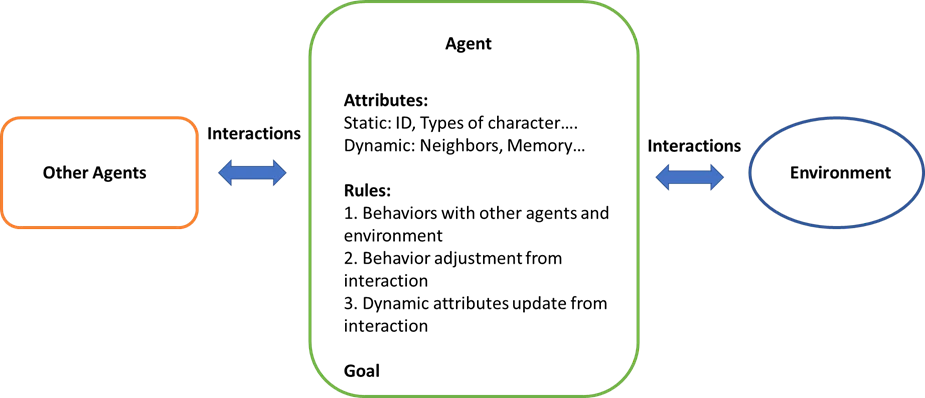


In the figure, we can see that there are static attributes and dynamic attributes. A static attribute is an attribute that will not change during the process of simulation, such as a consumer's name or a stock trader's company, etc. The dynamic attributes of an agent are attributes that will evolve during the simulation process. Agents'  memory is one example. An agent's memory at the initial stage can be different from their memory at different points in time as the simulation progresses. The memory is updated as the simulation operates. The neighbors of an agent are also a dynamic attribute. The neighbors around the agent during the very early stages can change as the simulation progresses and agents are allowed to move around. 

In the segregation model, the static attribute of the people is the group they are from. They can be from group X or group Y. The dynamic attributes of the people include the number of neighbors from the same group, the location where the people are located. The satisfaction benchmark is also dynamic. By changing the satisfaction benchmark, we will see the impact to the size of segregation clusters and the speed to ensure everyone is satisfied. 


### **1.2. Topology**

The next component of ABM is a scheme or a mechanism called **topology**. Topology is a set of rules describing an agent's behaviors, relationship with other agents, method of interacting with other agents and the environment, and possibly the agent's method to adapt after learning new information about other agents or the environment. It also provides guidelines on how an agent makes decisions. 

In the segregation model, we have rules to identify neighbors around a person. We also have a defined satisfaction benchmark for all people to decide if they would stay at their location or move. These rules constitute the topology of the segregation model. 


### **1.3. Environment**

Agents interact with their current environment. As such, the environment not only provides information to track an agent's location but can also be used for modeling. The environment can also serve as shocks that are administrated to the model. These shocks will affect agents' behaviors or topology rules. There can be endless shocks to the system. A researcher needs to have good subject knowledge to choose appropriate shocks to simulate.

In the segregation model, the grid where all people are assigned to live in is the environment. Within the grid, an agent is free to move around based on their same-type neighbor counts around them. 


## **2. ABM Results**

Once we have set up our agent-based model, we will use Monte Carlo to simulate the model repeatedly to generate multiple simulated outcomes to obtain the distribution of the outcomes and then summarize the outcomes. 

We have mentioned previously that an agent-based model produces a different output versus traditional models. Agent-based models have two types of outputs: process output and summary output. 

> **a.** The process output data comes from the evolution of the model and the components. <br>
> **b.** The summary output data comes from the final run of model simulations and average statistics from the multiple outcomes produced during the simulation.  <br>

The process output data usually is presented in a time series chart to display the evolution of agent's behavior. It can also show how the model works in action. This is very helpful to discover emerging phenomena from the model. The summary output data usually shows average statistics of the outcome during the whole simulation or a certain interval of the simulation. 

As we also mentioned previously, an agent-based model does not provide a forecasting function as is the case with traditional models. The main focus of agent-based models should be to detect emerging phenomena or interesting large patterns. 

In the segregation model section of Lesson 3 of this module, we showed the initial stage of the grid before the simulation and the finishing stage of the grid after simulation for the case of a satisfaction benchmark of 0.6. We can also show the progress of the percentage of people who are satisfied during the simulation. The following figure provides this example.


**Figure 2: The Grid after Simulation for Satisfaction Benchmark = 0.6 and Progress of Percentage of Satisfied People**


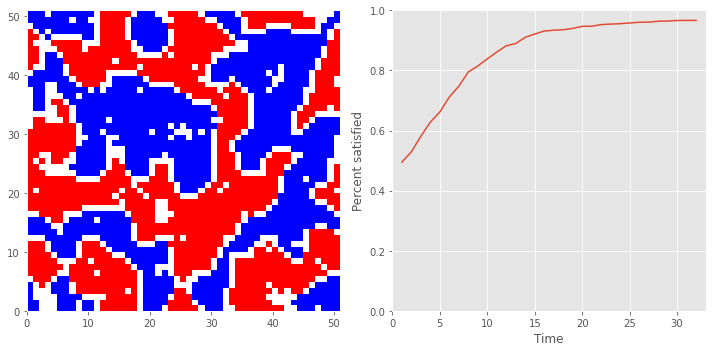


Figure 2 exhibits two plots from the simulations. The grid on the left is the final grid after simulation. We can see that there are clear clusters of segregated groups. On the right is the timelapse plot to show in which round of the simulation that all people are satisfied. We can see the simulation reaches all agent satisfaction around the 30th round. 


## **3. Model Validation**

Since agent-based modeling is a simulation-based modeling approach, it is difficult to validate the accuracy of the model. Unexpected results can come out of the simulation due to initial input data selection for the simulation or coding issue. Here are a few steps we can take to avoid the above issues.

**a. Computer Program Verification:**

Verification means that the computer program and simulation are running according to what is expected from the researcher's design. We can follow the usual computer programming quality control steps to avoid mistakes. Input data check should be included as well to make sure data has the features the model requires. For example, if the model needs stationary time series data, a unit root test should be performed in the program.

**b. Internal Validation:**

Validation is a process to check if there is a good agreement between an artificial model and the real-world system. There are two types of validation for ABM: Internal Validation and External Validation. Internal validation is when a researcher can be confident about the robustness of the results, and they are replicable as well as analytically adequate. It other words, the model should be able to correctly generate results predicted by the theory. There are occasions where a model focuses more on data mining and tries to find insights from the data using ABM without any theory. Then, it will be hard for this kind of model to pass internal validation. It does not mean the model is inadequate. When a researcher does not have a view about a dataset, conducting ABM to look for emerging phenomenon may produce useful insights.

**c. External Validation:**

External validation is the process of checking if the assumptions and structure of an ABM can be supported by empirical data or observed stylized facts from the real world. An externally validated ABM is a model that passes the test of a real-world system. These models generally focus more on modeling empirical regularities or looking for information to create a policy.

There can be trade-off between internal validity and external validity of an ABM as they have different priorities for validation. However, when validating an ABM, we should check both internal and external validity and make model adjustment decisions based on the focus of the research.


## **4. Application: Computer Program for Segregation Model**

In the previous sections, we talked about the theory of agent-based models and we used segregation model as an example to illustrate how agent-based model works. Since another important part of agent-based model is programming, we will provide the programming code for segregation models in this section. There are few of dedicated Python packages out there that automate building of the Agent Based Models with the further purpose of their usability or applications in various research fields such as Economics, Biology, Chemistry, etc. Here we implement the code in poor Python script. Python code in this lesson is based on the code developed by Geraint Ian Palmer (2017). This Python implementation employs object-oriented programming (OOP) features.

First, we create Agent class that initializes Agent object.


In [2]:
# Agent class


class Agent:
    # Initialize object
    def __init__(self, x, y, kind, preference, world):
        self.x = x
        self.y = y
        self.kind = kind
        self.preference = preference
        self.world = world

    # Method to gather array of neighbors' coordinates
    def know_neighbors(self):
        self.neighbors = [
            self.world.coords[x % self.world.size, y % self.world.size]
            for x, y in itertools.product(
                range(self.x - 1, self.x + 2), range(self.y - 1, self.y + 2)
            )
        ]

    # Method to define if cell is empty
    def vacant(self):
        return self.kind == 0

    # Method to measure happiness level
    def happiness(self):
        neighbor_kinds = [n.kind for n in self.neighbors]
        numsame = neighbor_kinds.count(self.kind)
        numvacant = neighbor_kinds.count(0)
        if numvacant == 8:
            if self.vacant():
                return 1.0
            return 0.0
        return (numsame - 1) / (8 - numvacant)

    # Method to check if agent is dissatisfied
    def dissatisfied(self):
        return self.happiness() < self.preference

    # Method to swap places with another cell
    def swap(self, partner):
        self.kind, partner.kind = partner.kind, self.kind

Agent object has the following attributes:

> - `x, y` are location coordinates;
> - `kind` is identification of kind represented by integers 0, 1 or 2. If agent is vacant cell than kind=0. If agent belongs to Group 1 (red cells) than kind=1. And if agent belongs to Group 2 (blue cells) than kind=2;
> - `preference` is Float number and indicates satisfaction benchmark;
> - `world` is object from World class (see below) where the agent belongs.


In object-oriented programming, a method is a programmed procedure or a way of doing something. Agent object has the following methods:

> - `know_neighbors()` method will identify adjacent cells (plots) and collect their coordinates in an array. There are 8 neighboring plots surrounding each agent. The model in this implementation assumes the world is a torus, that is the extreme left are neighbors to the extreme right, and the extreme top are neighbors with the extreme bottom.
> 
> - `vacant()` method simply checks if the cell we are examining is vacant.
>  
> - `happiness()` method is to measure happiness level of the agent. A agent's happiness level is measured by the percentage of neighbors of the same type among all neighbors. This is simply the ratio of the number of the neighbors that are in the same group as agent over the number of all non-vacant cells in neighborhood (8 minus vacant cells).
> 
> - `dissatisfied()` method is to check if agent is dissatisfied. This is when agent's happiness level is less than satisfaction benchmark. Satisfaction benchmark variable (preference) will be set to the value of 0.6 for the first part of the lesson.
> 
> - `swap(agent, partner)` method is to swap places with another cell. This is in order to enable moving the agent to the available vacant cell elsewhere.


Next, we introduce World class.

In [3]:
# World class (grid of squares to represent world)


class World:
    # Initialize object
    def __init__(self, size, kinds, probs, preference):
        self.size = size
        self.preference = preference
        self.coords = self.populate_world(kinds, probs, preference)
        [a.know_neighbors() for row in self.coords for a in row]
        self.num_dissatisfied = size**2
        self.num_vacant = sum([a.vacant() for row in self.coords for a in row])

    # Method to fill the world object grid with randomly placed vacant, red and blue cells
    def populate_world(self, kinds, probs, preference):
        return np.array(
            [
                [
                    Agent(x, y, np.random.choice(kinds, p=probs), preference, self)
                    for y in range(self.size)
                ]
                for x in range(self.size)
            ]
        )

    # Method to form array corresponding to the world object
    def atlas(self):
        return np.array([[a.kind for a in row] for row in self.coords])

    # Method to move unhappy agents to vacant plots
    def advance_turn(self):
        dissatisfied = []
        vacant = []
        for row in self.coords:
            for a in row:
                if a.vacant():
                    vacant.append(a)
                elif a.dissatisfied():
                    dissatisfied.append(a)
        self.num_dissatisfied = len(dissatisfied)
        np.random.shuffle(dissatisfied)
        np.random.shuffle(vacant)
        num_swap = min(self.num_dissatisfied, self.num_vacant)
        for indx in range(num_swap):
            dissatisfied[indx].swap(vacant[indx])

    # Method to measure happiness for each of the cell in the world grid and form array
    def happiness_distribution(self):
        return [a.happiness() for row in self.coords for a in row if not a.vacant()]

Objects in the World class have the following attributes:

> - `size` - this is dimension attribute. World object will have $\text{size} \times \text{size}$ grid dimension;
> - `kinds` - again this is the kind attribute but in this instance, it is given by the [0, 1, 2] list where all different types of kind indicators are listed. Here again 0 is kind indicator for vacant cell, 1 is kind indicator for agent from Group 1 (red cells) and 2 is kind indicator for agent from Group 2 (blue cells);
> - `probs` - this is parameter to indicate what proportion of the grid is occupied by each of different kinds of agents. It is given in the form [*proportion of empty cells, proportion of red cells, proportion of blue cells*] e.g.: [0.2, 0.4, 0.4];
> - `preference` - is given by Float number and indicates the satisfaction benchmark. In our model satisfaction benchmark is the same for all agents in the World grid;
> - `coords` - is attribute where all the agents' coordinates are collected in an array after calling `populate_world(kinds, probs, preference)` method (see below for details of this method);
> - `num_dissatisfied` - is a helper variable that is initially set to $\text{size}^2$. i.e. initial assumption is based on the idea that all agents are dissatisfied and are willing to move to vacant plots;
> - `num_vacant` - this attribute simply counts number of vacant plots at initial stage of the World object.


The World class object has following methods:

> - `populate_world(self, kinds, probs, preference)` - this method creates random sample of different kind agents from Agent class. The agents will be created according to specifications given in `kinds, probs, preference` elements. The result will be stored in an array of lists. Number of lists will be number indicated by $\text{size}$ attribute. Each list will have $\text{size}$ number of agent objects. So in total we have $\text{size} \times \text{size}$ number of agent objects in the final array.
> 
> - `atlas()` - this method creates an array of lists filled with kind indicators corresponding to the agent object that was created by the `populate_world(self, kinds, probs, preference)` method. Again, in total we have $\text{size} \times \text{size}$ number of items in the final array. Difference between the `atlas()` method and `populate_world(self, kinds, probs, preference)` method is that former stores only kind indicators whilst the latter stores agent objects.
> 
> - `advance_turn()` - this method moves unhappy agents to vacant plots. It first collects coordinates of dissatisfied agents and coordinates of vacant plots that are present in the World object. Identification of dissatisfied and vacant state is done by calling `dissatisfied()` method and `vacant()` method respectively.  The coordinates of dissatisfied agents and coordinates of vacant plots are stored in internal temporary variable lists `dissatisfied = []` and `vacant = []` respectively. This method then calls `swap(dissatisfied[i], vacant[i])` method to move dissatisfied agent on a vacant plot. Here the swap method will apply until all dissatisfied agents are moved or until vacant plots run out if the vacant plots are not enough to relocate all dissatisfied agents.
> 
> - `happiness_distribution()` - this method computes happiness rate for each of the non-vacant plot occupied by agent in the World object. This is done by calling `happiness()` method from Agent class. The results are stored in an array.



World class enables to create objects by populating atlas where `advance_turn()` and `happiness_distribution()` methods perform certain manipulations on them. All the manipulations are interactive and can modify initial state of the World class object. We will introduce another class, WorldArchiving class, below in order to have ability to take a snapshot image of the atlas after each round of simulation (turn) and to archive images.


In [4]:
# WorldArchiving class to preserve/archive the deep copy images of the world at each turn


class WorldArchiving(World):
    # Initialize objects
    def __init__(self, size, kinds, probs, preference):
        super(WorldArchiving, self).__init__(size, kinds, probs, preference)
        self.archived_atlases = []
        self.mean_happiness = [np.mean(self.happiness_distribution())]

    # Method that saves the deep copy image in archived_atlases array
    def archive(self):
        self.archived_atlases.append(copy.deepcopy(self.atlas()))

    # Method that moves unhappy agents, then saves the deep copy image of world grid
    # and mean happiness for each iteration until percent of unhappy agents is below threshold
    def play(self, threshold=0.01):
        self.archive()
        while self.num_dissatisfied / (self.size**2) > threshold:
            self.advance_turn()
            self.archive()
            self.mean_happiness.append(np.mean(self.happiness_distribution()))

WorldArchiving class inherits from World class. The objects from WorldArchiving class have all attributes inherited from World class and also have the following additional attributes:

> - `archived_atlases` - this attribute stores all archived atlas images in a list;
> - `mean_happiness` - this attribute is list of mean happiness values. The mean happiness value is computed by calling numpy mean operand on the results of `happiness_distribution()` method from World class. The mean happiness value is computed after each round of simulation (turn) of `play()`method (see below for method description).
        

The WorldArchiving class objects have two methods:

> - `archive()` - this method takes the deep copy of atlas created by `atlas()` method from World class and adds it to the `archived_atlases` attribute.
> 
> - `play(threshold=0.01)` - this method will apply consecutive rounds of simulations by calling `advance_turn()` method until all agents have happiness level above certain predefined threshold. During implementation this method simultaneously archives the deep copy images of atlas after each round of simulation and stores mean happiness values for each round. Number of rounds of simulations will vary for each world object and threshold value.

    

And finally, we introduce `plot_atlas_happiness(worlds, turn)` function. This function takes two arguments: *world* is World class object and *turn* is an integer to indicate round of simulation. The result will be combined plot of two subplots next to each other - one subplot is for archived world atlas image at certain round of simulation (turn) and second subplot is for happiness percent tracking. 

In [5]:
# Function that plots world atlas along with mean happiness for iteration level (turn)


def plot_atlas_happiness(worlds, turn):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    plt.style.use("ggplot")

    # Plot world atlas on left-hand-side
    cmap = ListedColormap(["white", "red", "blue"])
    ax[0].grid(False)
    ax[0].pcolor(worlds.archived_atlases[turn], cmap=cmap)

    # Plot happiness percent on right-hand-side
    ax[1].plot(
        range(1, len(worlds.archived_atlases[:turn]) + 1), worlds.mean_happiness[:turn]
    )
    plt.xlim([0, len(worlds.archived_atlases)])
    plt.ylim([0, 1])
    plt.xlabel("Time")
    plt.ylabel("Percent satisfied")
    plt.tight_layout()

    return fig

Now we are ready to create our World object. For this lesson we create the elements in a 51x51 squared grid, which creates 2,601 cells. 0.4 portion of them represent people from group 1 (group blue) and 0.4 portion of them represent people from group 2 (group red).  The rest belong to empty cells in the grid. For the first part of this lesson satisfaction benchmark variable (preference) is set to the value of 0.6. We then draw the grid in the initial stage before simulation together with corresponding happiness percent tracking plot. 

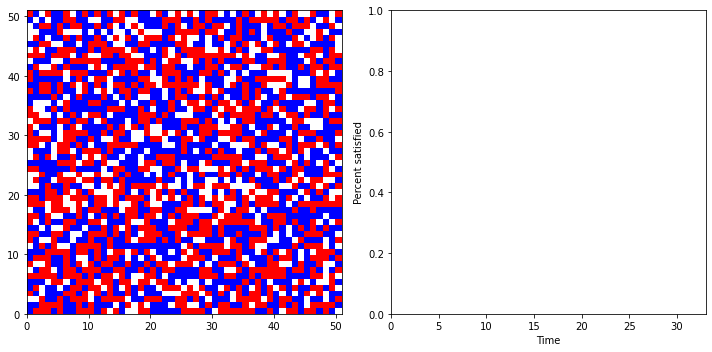

In [6]:
# Create 51x51 world grid with satisfaction benchmark 0.6 and
# randomly filled cells with:
#    0.2 portion of vacant cells,
#    0.4 portion of red cells and
#    0.4 portion of blue cells


np.random.seed(123)
worlds06 = WorldArchiving(51, [0, 1, 2], [0.2, 0.4, 0.4], 0.6)

# Apply play() method with zero threshold i.e until all agents are happy
worlds06.play(threshold=0.00)

# Plot world atlas and happiness level at the initial stage (turn=0)
plot_atlas_happiness(worlds06, turn=0)
plt.show()

In this piece of code above we have applied `worlds06.play(threshold=0.00)`. The processes involved in this operation can be summarized as follows: 

> a. Populate world with different kind of agents from Group 1 and Group 2 and vacant plots => <br>
> b. Take a snapshot image of the atlas => <br>
> b. Check each agent's neighbors => <br>
> b. Decide if each agent is dissatisfied with their neighborhood => <br>
> c. Repeat the process until all agents are checked => <br>
> d. Calculate the percentage of unhappy agents among all agents => <br>
> e. Move unhappy agents to a new location =>  <br>

These steps complete a round. Then, the code will continue with the next round until all agents have happiness level above *threshold=0.00*. The zero threshold in this case means that we leave no dissatisfied agents in the world grid. We can now plot the results of the final turn

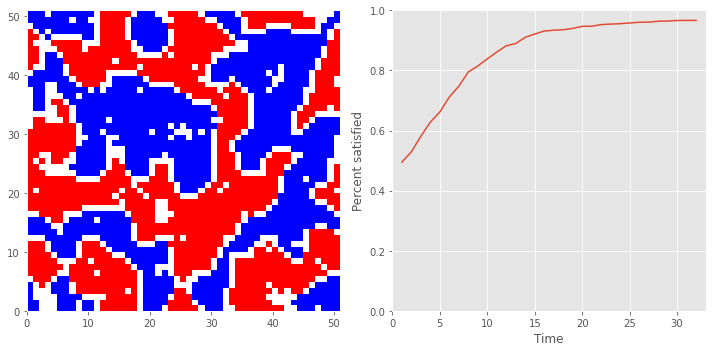

In [7]:
# Plot world atlas and happiness level at the final stage

plot_atlas_happiness(worlds06, len(worlds06.archived_atlases) - 1)
plt.show()

The plot above shows the final distribution of agents with the satisfaction benchmark = 0.6 on the left. We can see that there are clear clusters of the same group of agents who live close to each other. The plot on the right shows the percentage of happy agents among all agents at the end of each round. We can see that, after about 20th round, almost all agents are happy with their locations and there were almost no relocation actions. 

The above segregation model demonstrates how powerful ABM can be. Even with simple rules of agent's behavior, we can still find very interesting insights. For example, if we run the simulation with a satisfaction benchmark as low as 0.3, we see that agents can even start to segregate as the following plots show.


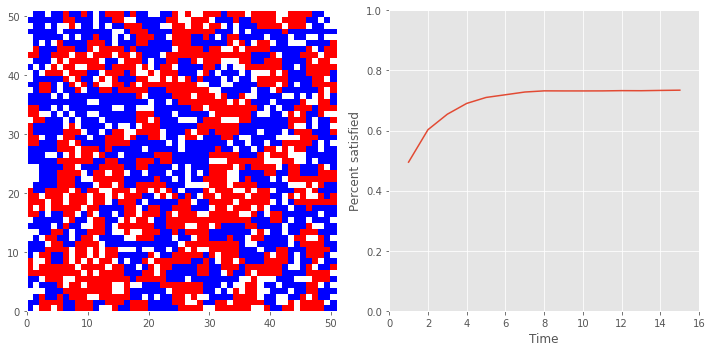

In [8]:
# Create 51x51 world grid with satisfaction benchmark 0.3 and
# randomly filled cells with:
#    0.2 portion of vacant cells,
#    0.4 portion of red cells and
#    0.4 portion of blue cells

np.random.seed(123)
worlds03 = WorldArchiving(51, [0, 1, 2], [0.2, 0.4, 0.4], 0.3)

# Apply play() method until all agents are happy
worlds03.play(threshold=0.00)

# Plot world atlas and happiness level at the final stage for satisfaction benchmark 0.3
plot_atlas_happiness(worlds03, len(worlds03.archived_atlases) - 1)
plt.show()

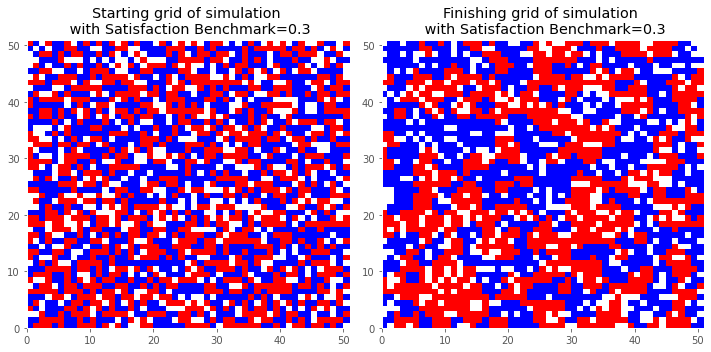

In [9]:
# Plot side-by-side plots of starting grid and finishing grid of the simulation with Satisfaction Benchmark=0.3
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
cmap = ListedColormap(["white", "red", "blue"])

# Plot starting grid of simulation
ax[0].grid(False)
ax[0].pcolor(worlds03.archived_atlases[0], cmap=cmap)
ax[0].set(title="Starting grid of simulation \n with Satisfaction Benchmark=0.3")

# Plot finishing grid of simulation
ax[1].grid(False)
ax[1].pcolor(worlds03.archived_atlases[len(worlds03.archived_atlases) - 1], cmap=cmap)
ax[1].set(title="Finishing grid of simulation \n with Satisfaction Benchmark=0.3")
plt.tight_layout()
plt.show()

## **5. Conclusion**

In this lesson, we continued our analysis of agent-based modeling. We discussed in detail the three components of ABM. We then talked about the types of result we usually get from ABM. Furthermore, we also touched upon the validation methods of ABM. We ended ABM with our segregation model with computer code to give students a better idea of how to implement an ABM. In the next lesson, we will move to a new topic: Classification.


## **References**

- Geraint Ian Palmer, "Schelling's segregation model", Aug 19 2017, http://www.geraintianpalmer.org.uk/2017/08/19/schelling-segregation/


---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
